Выполнение анализа зависимостей...
Карта сохранена в файл map.txt
Карта сохранена в файл map.txt
Карта сохранена в файл map.txt
Карта сохранена в файл map.txt
Карта сохранена в файл map.txt
Карта сохранена в файл map.txt


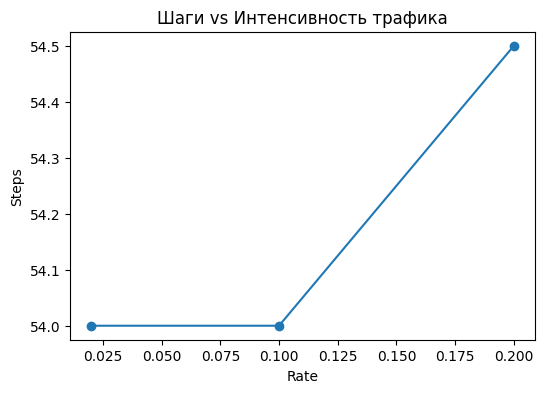

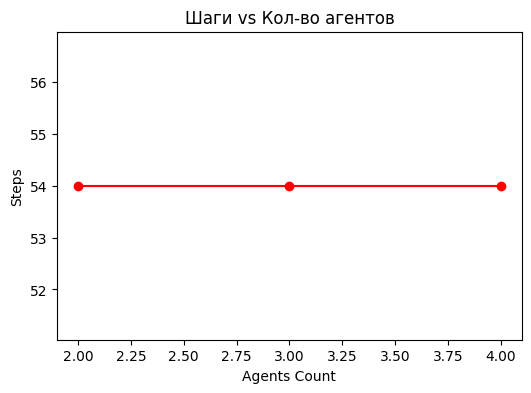

Графики сохранены как 'analysis_rates.png' и 'analysis_agents.png'
Подготовка анимации...
Карта сохранена в файл map.txt
Анимация сохранена в файл simulation.gif


In [12]:
import multiprocessing
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from queue import PriorityQueue
from IPython.display import HTML

EMPTY, WALL, START, SPAWN, GOAL, TRAFFIC, AGENT = 0, 1, 2, 3, 4, 5, 6
MAP_SIZE = 30

# Генерация карты
def generate_map():
    grid = [[0 for _ in range(MAP_SIZE)] for _ in range(MAP_SIZE)]
    for i in range(MAP_SIZE):
        grid[0][i] = grid[MAP_SIZE-1][i] = grid[i][0] = grid[i][MAP_SIZE-1] = WALL

    # Стены-кварталы
    for c in [6, 12, 18, 24]:
        for r in range(1, MAP_SIZE-1): grid[r][c] = WALL
    for r in [10, 20]:
        for c in range(1, MAP_SIZE-1): grid[r][c] = WALL

    # Проходы
    for c in [6, 12, 18, 24]:
        grid[5][c] = grid[15][c] = grid[25][c] = 0
    for r in [10, 20]:
        for c in [3, 9, 15, 21, 27]: grid[r][c] = 0

    start_pos = (28, 1)
    grid[start_pos[0]][start_pos[1]] = START
    goal_pos = (1, 28)
    grid[goal_pos[0]][goal_pos[1]] = GOAL
    spawn_points = [(2, 2), (2, 14), (15, 2), (15, 28), (28, 14)]
    for r, c in spawn_points: grid[r][c] = SPAWN

    with open("map.txt", "w") as f:
        for row in grid:
            line = "".join(map(str, row))
            f.write(line + "\n")
    print("Карта сохранена в файл map.txt")

    return grid, start_pos, goal_pos, spawn_points

def find_path(grid, start, goal):
    pq = PriorityQueue()
    pq.put((0, start))
    came_from, cost_so_far = {start: None}, {start: 0}
    while not pq.empty():
        _, current = pq.get()
        if current == goal: break
        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            next_node = (current[0] + dr, current[1] + dc)
            if 0 <= next_node[0] < MAP_SIZE and 0 <= next_node[1] < MAP_SIZE:
                if grid[next_node[0]][next_node[1]] != WALL:
                    new_cost = cost_so_far[current] + 1
                    if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                        cost_so_far[next_node] = new_cost
                        priority = new_cost + abs(goal[0]-next_node[0]) + abs(goal[1]-next_node[1])
                        pq.put((priority, next_node))
                        came_from[next_node] = current
    if goal not in came_from: return None
    path = []
    curr = goal
    while curr != start:
        path.append(curr); curr = came_from[curr]
    path.reverse()
    return path

# Логика агентов
def traffic_process(start_pos, shared_grid, lock, stop_event, lifetime):
    current_pos, prev_move, steps = start_pos, None, 0
    try:
        while not stop_event.is_set() and steps < lifetime:
            time.sleep(0.05)
            r, c = current_pos
            moves = []
            for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                nr, nc = r+dr, c+dc
                if 0 <= nr < MAP_SIZE and 0 <= nc < MAP_SIZE and shared_grid[nr*MAP_SIZE+nc] != WALL:
                    moves.append((dr, dc))
            if not moves: break

            if prev_move and prev_move in moves and random.random() < 0.7:
                next_move = prev_move
            else:
                next_move = random.choice(moves)

            nr, nc = r+next_move[0], c+next_move[1]
            with lock:
                if shared_grid[nr*MAP_SIZE+nc] not in [TRAFFIC, AGENT, WALL]:
                    shared_grid[r*MAP_SIZE+c] = 0
                    shared_grid[nr*MAP_SIZE+nc] = TRAFFIC
                    current_pos, prev_move = (nr, nc), next_move
            steps += 1
    finally:
        with lock:
            if shared_grid[current_pos[0]*MAP_SIZE+current_pos[1]] == TRAFFIC:
                shared_grid[current_pos[0]*MAP_SIZE+current_pos[1]] = 0

def delivery_process(start_pos, goal_pos, shared_grid, lock, stop_event, results):
    temp_grid = np.array(shared_grid).reshape(MAP_SIZE, MAP_SIZE)
    path = find_path(temp_grid, start_pos, goal_pos)
    if not path: return
    current_pos, idx, steps = start_pos, 0, 0
    try:
        while not stop_event.is_set() and current_pos != goal_pos:
            time.sleep(0.05)
            if idx >= len(path): break
            next_node = path[idx]
            with lock:
                if shared_grid[next_node[0]*MAP_SIZE+next_node[1]] not in [TRAFFIC, AGENT, WALL]:
                    shared_grid[current_pos[0]*MAP_SIZE+current_pos[1]] = 0
                    shared_grid[next_node[0]*MAP_SIZE+next_node[1]] = AGENT
                    current_pos = next_node
                    idx += 1
            steps += 1
        if current_pos == goal_pos: results.append(steps)
    finally:
        with lock:
            if shared_grid[current_pos[0]*MAP_SIZE+current_pos[1]] == AGENT:
                shared_grid[current_pos[0]*MAP_SIZE+current_pos[1]] = 0

def traffic_gen_process(spawn_points, rate, shared_grid, lock, stop_event):
    procs = []
    while not stop_event.is_set():
        time.sleep(0.2)
        if random.random() < rate:
            p = multiprocessing.Process(target=traffic_process, args=(random.choice(spawn_points), shared_grid, lock, stop_event, random.randint(15, 150)))
            p.start(); procs.append(p)
        procs = [p for p in procs if p.is_alive()]

# Эксперимент
def run_simulation(num_agents, rate, collect_history=False):
    grid, start, goal, spawns = generate_map()
    manager = multiprocessing.Manager()
    shared_grid = manager.list(np.array(grid).flatten())
    lock, stop_event, results = manager.Lock(), manager.Event(), manager.list()

    t_gen = multiprocessing.Process(target=traffic_gen_process, args=(spawns, rate, shared_grid, lock, stop_event))
    t_gen.start()

    agents = [multiprocessing.Process(target=delivery_process, args=(start, goal, shared_grid, lock, stop_event, results)) for _ in range(num_agents)]
    for a in agents: a.start(); time.sleep(0.2)

    history = []
    timeout = 300
    for _ in range(timeout):
        if len(results) >= num_agents: break
        if collect_history: history.append(list(shared_grid))
        time.sleep(0.1)

    stop_event.set()
    t_gen.join()
    for a in agents: a.join()

    return list(results), history

# Построение графиков по результатам
def perform_analysis():
    """Функция для запуска графиков и сохранения их в PNG (Ячейка 1)"""
    print("Выполнение анализа зависимостей...")
    rates = [0.02, 0.1, 0.2]
    counts = [2, 3, 4]

    res_rates = []
    for r in rates:
        s, _ = run_simulation(2, r)
        res_rates.append(np.mean(s) if s else 0)

    res_counts = []
    for c in counts:
        s, _ = run_simulation(c, 0.05)
        res_counts.append(np.mean(s) if s else 0)

    plt.figure(figsize=(6, 4))
    plt.plot(rates, res_rates, 'o-')
    plt.title("Шаги vs Интенсивность трафика")
    plt.xlabel("Rate")
    plt.ylabel("Steps")
    plt.savefig("analysis_rates.png")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(counts, res_counts, 'o-r')
    plt.title("Шаги vs Кол-во агентов")
    plt.xlabel("Agents Count")
    plt.ylabel("Steps")
    plt.savefig("analysis_agents.png")
    plt.show()

    print("Графики сохранены как 'analysis_rates.png' и 'analysis_agents.png'")

def show_animation():
    """Функция для визуализации и сохранения в GIF (Ячейка 2)"""
    print("Подготовка анимации...")
    _, history = run_simulation(2, 0.08, collect_history=True)
    if not history:
        print("История пуста.")
        return
    fig, ax = plt.subplots(figsize=(6,6))
    cmap = plt.cm.colors.ListedColormap(['white', 'black', 'lime', 'orange', 'red', 'blue', 'purple'])

    def update(i):
        ax.clear()
        ax.imshow(np.array(history[i]).reshape(30,30), cmap=cmap)
        ax.axis('off')

    ani = animation.FuncAnimation(fig, update, frames=len(history), interval=100)

    try:
        ani.save('simulation.gif', writer='pillow', fps=10)
        print("Анимация сохранена в файл simulation.gif")
    except Exception as e:
        print(f"Не удалось сохранить GIF: {e}. Убедитесь, что установлена библиотека pillow.")

    plt.close()
    return HTML(ani.to_jshtml())

if __name__ == "__main__":
    perform_analysis()

show_animation()